# Minor Project – Sales Performance Analysis System

> Done by Pranav Jahagirdar

### Problem Statement

Organizations collect daily sales data but often lack clarity about revenue trends,
regional performance, and category-wise contribution.

This project analyzes a product sales dataset to:
- Understand overall revenue and profit
- Identify top-performing categories and products
- Analyze regional performance
- Visualize revenue trends over time

## Complete code

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [17]:
df = pd.read_csv("4876484-Product_Sales_Dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


In [18]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.describe()

Shape of dataset: (10000, 14)

Columns:
Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'State', 'Region',
       'Country', 'Category', 'Sub_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Revenue', 'Profit'],
      dtype='object')

Data Types:
Order_ID           int64
Order_Date        object
Customer_Name     object
City              object
State             object
Region            object
Country           object
Category          object
Sub_Category      object
Product_Name      object
Quantity           int64
Unit_Price       float64
Revenue          float64
Profit           float64
dtype: object


,Order_ID,Quantity,Unit_Price,Revenue,Profit
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.849600,385.353689,715.869528,157.122257
std,2886.89568,1.088714,277.509694,738.705012,150.634933
min,1.00000,1.000000,19.730000,20.300000,4.360000
25%,2500.75000,1.000000,164.827500,230.222500,59.320000
50%,5000.50000,1.000000,308.140000,473.755000,110.405000
75%,7500.25000,2.000000,566.147500,890.640000,203.160000
max,10000.00000,8.000000,1372.890000,7110.960000,1760.890000


In [19]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Order_ID         0
Order_Date       0
Customer_Name    0
City             0
State            0
Region           0
Country          0
Category         0
Sub_Category     0
Product_Name     0
Quantity         0
Unit_Price       0
Revenue          0
Profit           0
dtype: int64


In [20]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Null dates after conversion:", df["Order_Date"].isnull().sum())

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()

df.head()

Null dates after conversion: 0


/tmp/ipython-input-3617970723.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit,Year,Month,Month_Name
0,1,2023-08-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49,2023,8,August
1,2,2024-12-20,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09,2024,12,December
2,3,2024-01-29,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47,2024,1,January
3,4,2024-11-29,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38,2024,11,November
4,5,2023-09-21,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46,2023,9,September


In [21]:
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
average_order_value = df["Revenue"].mean()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Average Order Revenue:", average_order_value)

Total Revenue: 7158695.279999999
Total Profit: 1571222.5700000003
Average Order Revenue: 715.869528


In [22]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

category_revenue

,Revenue
Category,
Electronics,2923782.77
Home & Furniture,2385671.95
Clothing & Apparel,1350706.07
Accessories,498534.49


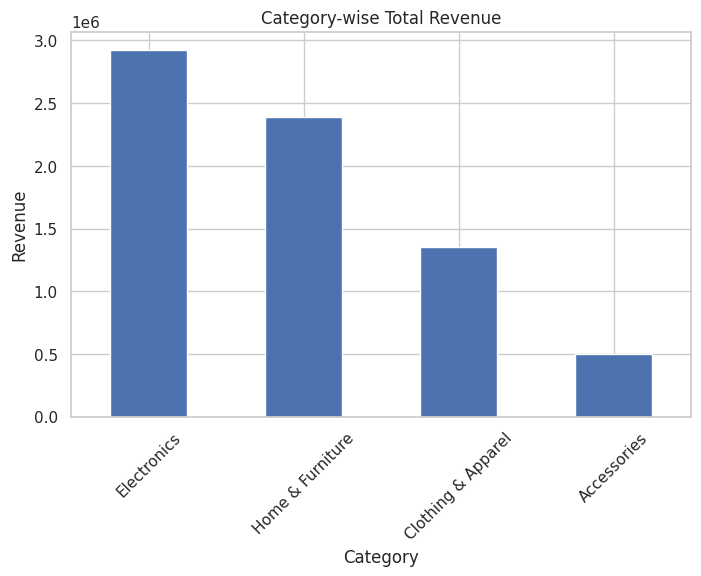

In [23]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title("Category-wise Total Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [24]:
region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

region_revenue

,Revenue
Region,
East,2340783.22
Centre,1766154.12
West,1751011.36
South,1300746.58


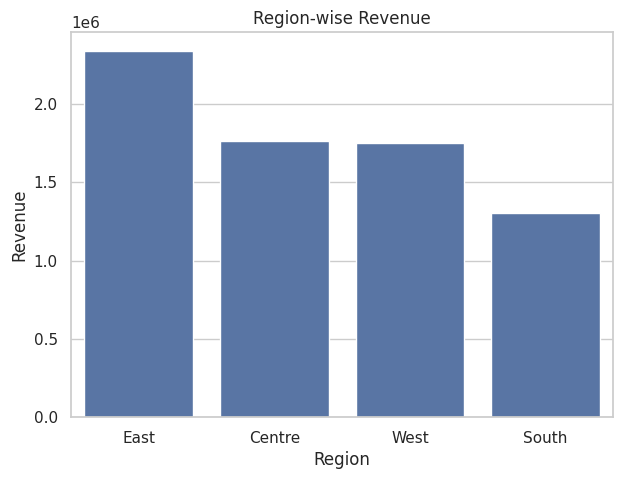

In [25]:
plt.figure(figsize=(7,5))
sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

In [26]:
monthly_revenue = df.groupby("Month_Name")["Revenue"].sum()

# To sort months properly
monthly_revenue = monthly_revenue.reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

monthly_revenue

,Revenue
Month_Name,
January,440618.00
February,272790.65
March,422089.97
April,431275.23
May,470486.14
June,460982.41
July,459866.86
August,459234.58
September,474217.93


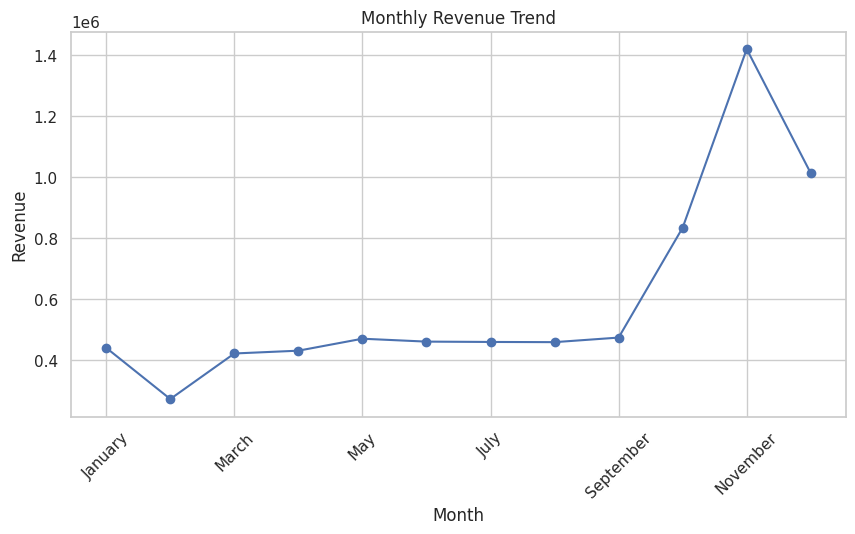

In [27]:
plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [28]:
top_products = df.groupby("Product_Name")["Revenue"].sum().sort_values(ascending=False).head(5)

top_products

,Revenue
Product_Name,
Instant Pot,476407.43
MacBook Air,441150.74
Tempur-Pedic Mattress,421425.57
Apple Watch,317984.98
Apple iPhone 14,307399.56


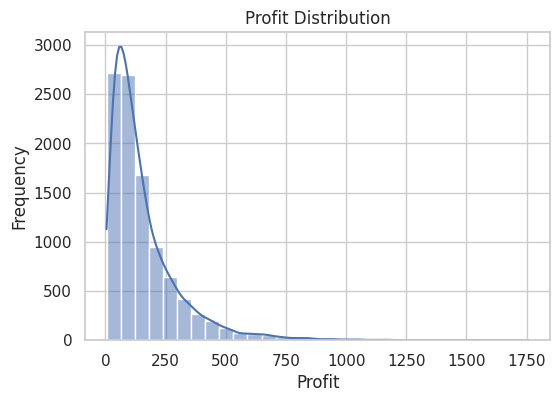

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df["Profit"], bins=30, kde=True)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

## Key Findings

1. The total revenue and profit indicate overall business performance.
2. Certain categories contribute significantly more revenue.
3. Revenue varies across regions, indicating geographic demand differences.
4. Monthly trends show seasonal fluctuations.
5. A small number of products contribute heavily to total revenue.

These insights can help management:
- Focus on high-performing categories
- Improve strategies in low-performing regions
- Plan inventory based on seasonal trends

## Conclusion

This project successfully:

- Cleaned and structured the sales dataset
- Performed exploratory data analysis
- Identified revenue, profit, and regional trends
- Visualized business insights using Matplotlib and Seaborn

The analysis demonstrates how Python and Pandas can transform raw data
into actionable business decisions.